## AKANSHA SINGH
## ROLL NO: 241561503
## ASSIGNMENT 4

In [201]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from six import StringIO
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.tree import export_graphviz
from IPython.display import Image  
import pydotplus
from IPython.display import Image 

import dtreeviz
from tensorflow.keras.models  import Sequential,load_model
from tensorflow.keras.layers  import Dense

df = pd.read_csv("Telco-Customer-Churn__1.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


### Categorizing Tenure into more suitable categories:


In [203]:
def tenure_term(size):
    if size in range(1,13):
        return 'Small'
    elif size in range(13,50):
        return 'Medium'
    else:
        return 'Large'

In [204]:
df['tenure_size']=df['tenure'].apply(tenure_term)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_size
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Small
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Small
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,Medium
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,Large
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,Small
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes,Small


### Converting categorical variable into numerical values

In [206]:
def generatenumber(value):
    if value == 'Yes':
        return 1
    else:
        return 0

In [207]:
df['OnlineSecurity']=df['OnlineSecurity'].apply(generatenumber)
df['PaperlessBilling']=df['PaperlessBilling'].apply(generatenumber)
df['DeviceProtection']=df['DeviceProtection'].apply(generatenumber)
df['Partner']=df['Partner'].apply(generatenumber)
df['Dependents']=df['Dependents'].apply(generatenumber)
df['TechSupport']=df['TechSupport'].apply(generatenumber)
df['StreamingTV']=df['StreamingTV'].apply(generatenumber)
df['StreamingMovies']=df['StreamingMovies'].apply(generatenumber)
df['Churn']=df['Churn'].apply(generatenumber)
df['PhoneService']=df['PhoneService'].apply(generatenumber)


In [208]:
def generatenumber_InternetService(value):
    if value == 'DSL':
        return 1
    elif value == 'Fiber optic':
        return 2
    else:
        return 0

In [209]:
df['InternetService'] = df['InternetService'].apply(generatenumber_InternetService)


In [210]:
def generatenumber_Gender(value):
    if value == 'Male':
        return 1
    else:
        return 0

In [211]:
df['gender'] = df['gender'].apply(generatenumber_Gender)


In [212]:
def generatenumber_PaymentMethod(value):
    if value == 'Mailed check':
        return 1
    elif value == 'Bank transfer (automatic)':
        return 2
    else:
        return 0

In [213]:
df['PaymentMethod'] = df['PaymentMethod'].apply(generatenumber_PaymentMethod)


In [214]:
def generatenumber_Contract(value):
    if value == 'One year':
        return 1
    elif value == 'Two year':
        return 2
    else:
        return 0

In [215]:
df['Contract'] = df['Contract'].apply(generatenumber_Contract)


In [216]:
def generatenumber_MultipleLines(value):
    if value == 'Yes':
        return 1
    elif value == 'No':
        return 0
    else:
        return 2

In [217]:
df['MultipleLines'] = df['MultipleLines'].apply(generatenumber_MultipleLines)


In [218]:
def generatenumber_TenureSize(value):
    if value == 'Small':
        return 0
    elif value == 'Medium':
        return 1
    else:
        return 2

In [219]:
df['tenure_size'] = df['tenure_size'].apply(generatenumber_TenureSize)


### Dropping customerID as it is irrelevant in generating tree

In [221]:
df.drop('customerID', axis = 1,inplace = True)


In [222]:
def generatenumber_backup(value):
    if value == 'Yes':
        return 1
    elif value == 'No':
        return 0
    else:
        return 2

In [223]:
df['OnlineBackup']=df['OnlineBackup'].apply(generatenumber_backup)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_size
0,0,0,1,0,1,0,2,1,0,1,...,0,0,0,0,1,0,29.85,29.85,0,0
1,1,0,0,0,34,1,0,1,1,0,...,0,0,0,1,0,1,56.95,1889.5,0,1
2,1,0,0,0,2,1,0,1,1,1,...,0,0,0,0,1,1,53.85,108.15,1,0
3,1,0,0,0,45,0,2,1,1,0,...,1,0,0,1,0,2,42.30,1840.75,0,1
4,0,0,0,0,2,1,0,2,0,0,...,0,0,0,0,1,0,70.70,151.65,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,1,1,0,...,1,1,1,1,1,1,84.80,1990.5,0,1
7039,0,0,1,1,72,1,1,2,0,1,...,0,1,1,1,1,0,103.20,7362.9,0,2
7040,0,0,1,1,11,0,2,1,1,0,...,0,0,0,0,1,0,29.60,346.45,0,0
7041,1,1,1,0,4,1,1,2,0,0,...,0,0,0,0,1,1,74.40,306.6,1,0


##

##

# Build and Compile Model

In [227]:
#split dataset in features and target variable
feature_cols = ['tenure_size', 'OnlineSecurity', 'PaymentMethod','Contract','MonthlyCharges']
X = df[feature_cols] # Features
y = df['Churn'] # Target variable


# Split dataset into training set and test set
x_train,x_test,y_train,y_test = train_test_split(X,y,stratify=y)
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

# Standard Scaler
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)


clf = tree.DecisionTreeClassifier(criterion = 'gini',max_leaf_nodes = 3)
clf.fit(x_train,y_train)
y_train_pred = clf.predict(x_train)
y_pred = clf.predict(x_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy : ",accuracy_score(y_test, y_pred)*100)


Accuracy :  75.97955706984668


### Using Rectified Linear activation function

In [229]:
# Building the ANN

model = Sequential()
model.add(Dense(units = 32, activation = 'relu',input_dim=x_train.shape[1]))
model.add(Dense(units = 64, activation = 'relu'))
model.add(Dense(units = 1, activation = 'sigmoid'))

C:\Users\91809\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


In [230]:
# Model Summary

model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                     │ (None, 32)                  │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,369 (9.25 KB)

 Trainable params: 2,369 (9.25 KB)

 Non-trainable params: 0 (0.00 B)

In [231]:
# Compile the model
model.compile(loss = 'binary_crossentropy',optimizer = 'sgd',metrics=['accuracy'])

In [232]:
# Train the model

history = model.fit(x_train, y_train,epochs = 200, batch_size = 32,validation_data=(x_test_scaled,y_test))

Epoch 1/200
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5872 - loss: 0.6439 - val_accuracy: 0.7348 - val_loss: 0.4989
Epoch 2/200
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7310 - loss: 0.5007 - val_accuracy: 0.7348 - val_loss: 0.4673
Epoch 3/200
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7448 - loss: 0.4719 - val_accuracy: 0.7751 - val_loss: 0.4512
Epoch 4/200
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7796 - loss: 0.4567 - val_accuracy: 0.7768 - val_loss: 0.4416
Epoch 5/200
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7740 - loss: 0.4488 - val_accuracy: 0.7785 - val_loss: 0.4359
Epoch 6/200
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7818 - loss: 0.4468 - val_accuracy: 0.7836 - val_loss: 0.4323
Epoch 7/200
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7813 - loss: 0.4399 - val_accuracy: 0.7814 - val_loss: 0.4300
Epoch 8/200
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7908 - loss: 0.4349 - val_accu

<function matplotlib.pyplot.show(close=None, block=None)>

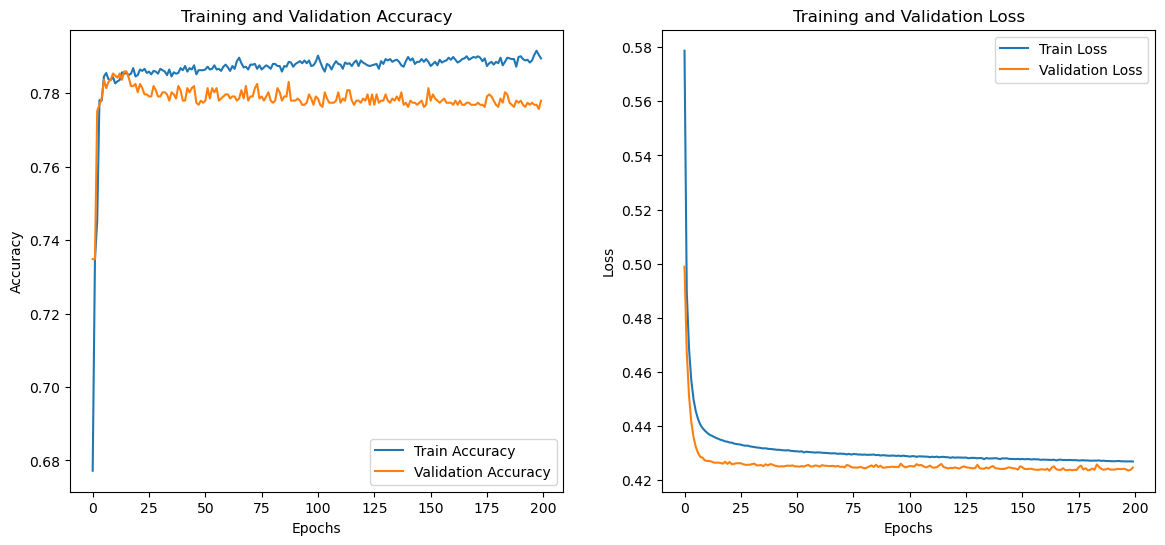

In [233]:
# Plotting the training and validation accuracy/loss
plt.figure(figsize=(14, 6))
# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show

In [234]:
y_hat = model.predict(x_test)
y_hat = [0 if val <0.5 else 1 for val in y_hat]
print("Accuracy:")
accuracy_score(y_test,y_hat)


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy:


0.7779670641680864

#### After training the model the accuracy is 78%

### Using Rectified Linear activation function

In [237]:
#split dataset in features and target variable
feature_cols = ['tenure_size', 'OnlineSecurity', 'PaymentMethod','Contract','MonthlyCharges']
X = df[feature_cols] # Features
y = df['Churn'] # Target variable

# Standard Scaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split dataset into training set and test set
x_train,x_test,y_train,y_test = train_test_split(X,y,stratify=y)
print(x_train.shape)
print(x_test.shape)

# Generating scaled values
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

clf = tree.DecisionTreeClassifier(criterion = 'gini',max_depth = 3, random_state=0,splitter = 'best')
clf.fit(x_train,y_train)
y_train_pred = clf.predict(x_train)
y_pred = clf.predict(x_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy : ",accuracy_score(y_test, y_pred)*100)

# Building the ANN

model = Sequential()
model.add(Dense(units = 32, activation = 'relu',input_dim=x_train.shape[1]))
model.add(Dense(units = 64, activation = 'relu'))
model.add(Dense(units = 1, activation = 'sigmoid'))




(5282, 5)
(1761, 5)
Accuracy :  77.56956274843839


C:\Users\91809\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


In [238]:
# compile the model

model.compile(loss = 'binary_crossentropy',optimizer = 'sgd',metrics=['accuracy'])

# Train The ANN

model.fit(x_train, y_train,epochs = 1000, batch_size = 32, validation_data=(x_test_scaled,y_test))

Epoch 1/1000
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7025 - loss: 0.5856 - val_accuracy: 0.7348 - val_loss: 0.5067
Epoch 2/1000
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - accuracy: 0.7333 - loss: 0.4883 - val_accuracy: 0.7473 - val_loss: 0.4813
Epoch 3/1000
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - accuracy: 0.7642 - loss: 0.4570 - val_accuracy: 0.7683 - val_loss: 0.4696
Epoch 4/1000
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - accuracy: 0.7798 - loss: 0.4460 - val_accuracy: 0.7683 - val_loss: 0.4634
Epoch 5/1000
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 886us/step - accuracy: 0.7739 - loss: 0.4512 - val_accuracy: 0.7700 - val_loss: 0.4602
Epoch 6/1000
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - accuracy: 0.7962 - loss: 0.4325 - val_accuracy: 0.7666 - val_loss: 0.4582
Epoch 7/1000
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7887 - loss: 0.4397 - val_accuracy: 0.7689 - val_loss: 0.4571
Epoch 8/1000
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step - accuracy: 0.7822 - los

<function matplotlib.pyplot.show(close=None, block=None)>

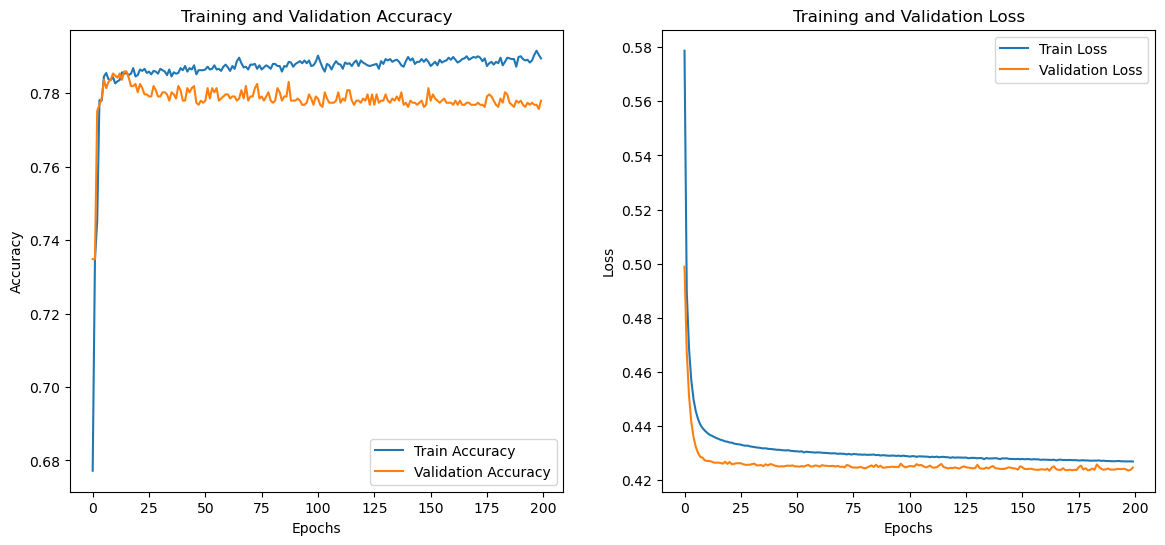

In [239]:
# Plotting the training and validation accuracy/loss
plt.figure(figsize=(14, 6))
# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label= 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show

In [240]:
# Model Summary

model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                     │ (None, 32)                  │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,371 (9.27 KB)

 Trainable params: 2,369 (9.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [241]:
# prediciting the Model Values

y_hat = model.predict(x_test)
y_hat = [0 if val <0.5 else 1 for val in y_hat]
print("Accuracy:")
accuracy_score(y_test,y_hat)


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy:


0.778534923339012

#### After training the model the accuracy is 78%

### Using Rectified Linear activation function with maxdepth = 4

In [244]:
#split dataset in features and target variable
feature_cols = ['tenure_size', 'OnlineSecurity', 'PaymentMethod','Contract','MonthlyCharges','PhoneService','MultipleLines','InternetService','PaperlessBilling']
X = df[feature_cols] # Features
y = df['Churn'] # Target variable

# Standard Scaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split dataset into training set and test set
x_train,x_test,y_train,y_test = train_test_split(X,y,stratify=y)
print(x_train.shape)
print(x_test.shape)

# Generating scaled values
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

clf = tree.DecisionTreeClassifier(criterion = 'entropy',max_depth =4, random_state=0,splitter = 'best')
clf.fit(x_train,y_train)
y_train_pred = clf.predict(x_train)
y_pred = clf.predict(x_test)


# Model Accuracy, how often is the classifier correct?
print("Accuracy : ",accuracy_score(y_test, y_pred)*100)

# Build the ANN
model = Sequential()
model.add(Dense(units = 32, activation = 'relu',input_dim=x_train.shape[1]))
model.add(Dense(units = 64, activation = 'relu'))
model.add(Dense(units = 1, activation = 'sigmoid'))


(5282, 9)
(1761, 9)
Accuracy :  77.11527541169791


C:\Users\91809\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


In [245]:
# Compile the ANN
model.compile(loss = 'binary_crossentropy',optimizer = 'sgd',metrics=['accuracy'])

# Model Summary
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                     │ (None, 32)                  │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [246]:
#Train the ANN
model.fit(x_train, y_train,epochs = 500, batch_size = 32,validation_data=(x_test_scaled,y_test))

Epoch 1/500
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7127 - loss: 0.6033 - val_accuracy: 0.7348 - val_loss: 0.5115
Epoch 2/500
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7502 - loss: 0.4949 - val_accuracy: 0.7734 - val_loss: 0.4775
Epoch 3/500
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7837 - loss: 0.4550 - val_accuracy: 0.7746 - val_loss: 0.4612
Epoch 4/500
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7738 - loss: 0.4399 - val_accuracy: 0.7768 - val_loss: 0.4537
Epoch 5/500
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7900 - loss: 0.4268 - val_accuracy: 0.7825 - val_loss: 0.4499
Epoch 6/500
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7812 - loss: 0.4385 - val_accuracy: 0.7814 - val_loss: 0.4470
Epoch 7/500
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7896 - loss: 0.4341 - val_accuracy: 0.7859 - val_loss: 0.4457
Epoch 8/500
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8010 - loss: 0.4154 - val_accu

<function matplotlib.pyplot.show(close=None, block=None)>

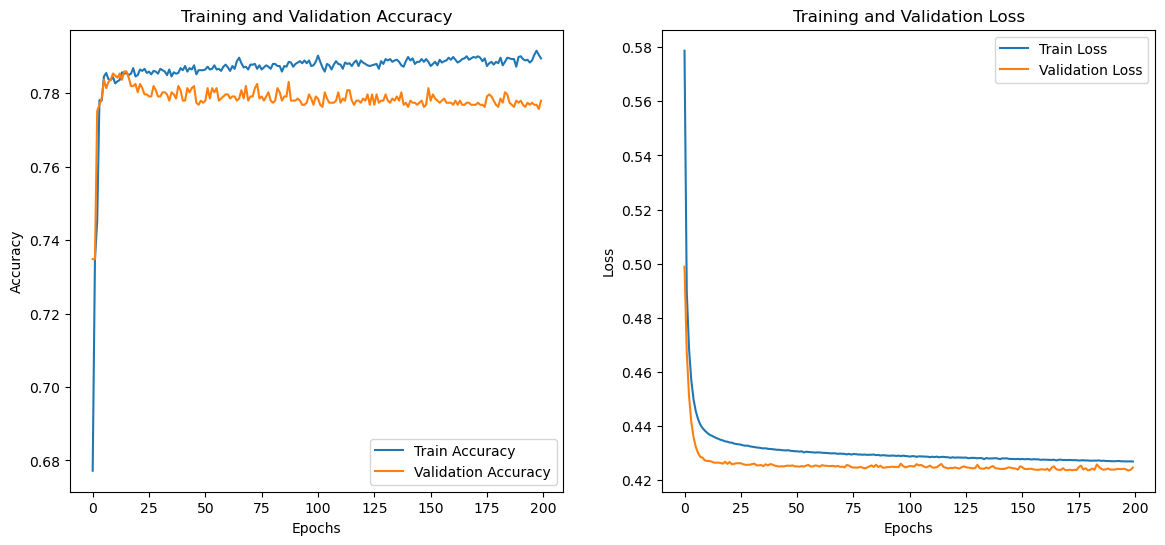

In [247]:
# Plotting the training and validation accuracy/loss
plt.figure(figsize=(14, 6))
# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show

In [248]:
# Predict the values
y_hat = model.predict(x_test)
y_hat = [0 if val <0.5 else 1 for val in y_hat]
print("Accuracy:")
accuracy_score(y_test,y_hat)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy:


0.7808063600227144

#### Accuray of the traning model is 77%

## Using Softmax Activation Function

In [251]:
#split dataset in features and target variable
feature_cols = ['tenure_size', 'OnlineSecurity', 'PaymentMethod','Contract','MonthlyCharges','PhoneService','MultipleLines','InternetService','PaperlessBilling']
X = df[feature_cols] # Features
y = df['Churn'] # Target variable

# Standard Scaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split dataset into training set and test set
x_train,x_test,y_train,y_test = train_test_split(X,y,stratify=y)
print(x_train.shape)
print(x_test.shape)

# Generating scaled values
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

clf = tree.DecisionTreeClassifier(criterion = 'entropy',max_depth =4, random_state=0,splitter = 'best')
clf.fit(x_train,y_train)
y_train_pred = clf.predict(x_train)
y_pred = clf.predict(x_test)


# Model Accuracy, how often is the classifier correct?
print("Accuracy : ",accuracy_score(y_test, y_pred)*100)


model = Sequential()
model.add(Dense(units = 32, activation = 'softmax',input_dim=x_train.shape[1]))
model.add(Dense(units = 64, activation = 'softmax'))
model.add(Dense(units = 128, activation = 'softmax'))
model.add(Dense(units = 1, activation = 'sigmoid'))


model.compile(loss = 'binary_crossentropy',optimizer = 'sgd',metrics=['accuracy'])

model.summary()



(5282, 9)
(1761, 9)
Accuracy :  79.1595684270301


C:\Users\91809\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                     │ (None, 32)                  │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,881 (42.50 KB)

 Trainable params: 10,881 (42.50 KB)

 Non-trainable params: 0 (0.00 B)

In [252]:
history = model.fit(x_train, y_train,epochs = 500, batch_size = 32,validation_data=(x_test_scaled,y_test))

Epoch 1/500
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7339 - loss: 0.6720 - val_accuracy: 0.7348 - val_loss: 0.6302
Epoch 2/500
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7343 - loss: 0.6219 - val_accuracy: 0.7348 - val_loss: 0.6030
Epoch 3/500
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7423 - loss: 0.5949 - val_accuracy: 0.7348 - val_loss: 0.5902
Epoch 4/500
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7245 - loss: 0.5957 - val_accuracy: 0.7348 - val_loss: 0.5840
Epoch 5/500
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7350 - loss: 0.5831 - val_accuracy: 0.7348 - val_loss: 0.5813
Epoch 6/500
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 0.5847 - val_accuracy: 0.7348 - val_loss: 0.5799
Epoch 7/500
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7429 - loss: 0.5724 - val_accuracy: 0.7348 - val_loss: 0.5792
Epoch 8/500
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7363 - loss: 0.5777 - val_accu

<function matplotlib.pyplot.show(close=None, block=None)>

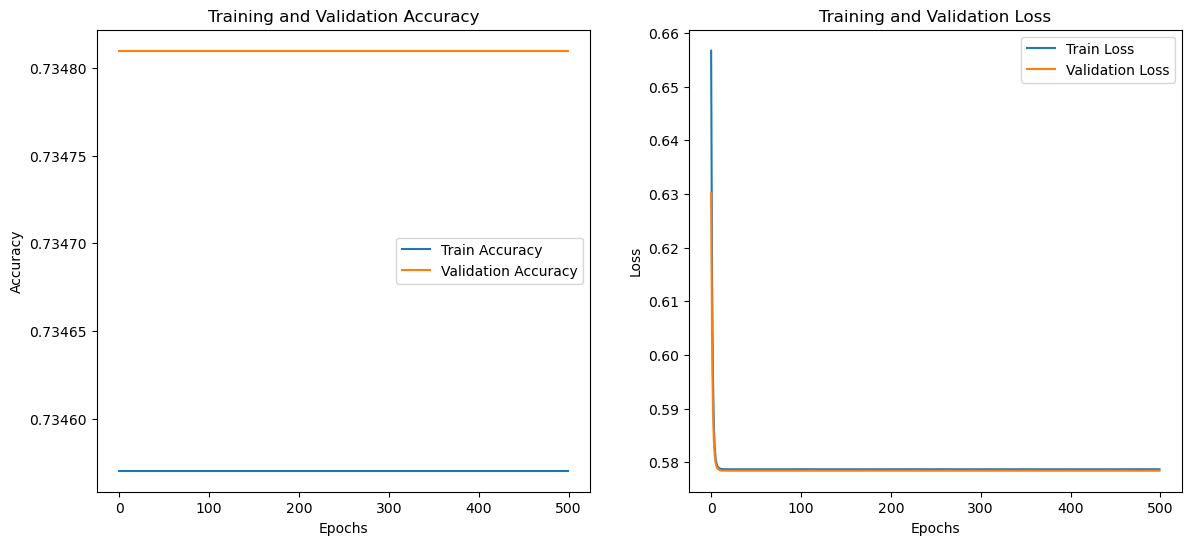

In [253]:
# Plotting the training and validation accuracy/loss
plt.figure(figsize=(14, 6))
# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show

In [254]:
y_hat = model.predict(x_test)
y_hat = [0 if val <0.5 else 1 for val in y_hat]
print("Accuracy:")
accuracy_score(y_test,y_hat)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy:


0.7348097671777399

#### Accuracy of the traning model is 73%

In [298]:
# Generate the Confusion matrix
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test,y_pred)


[[1232   62]
 [ 305  162]]


0.7915956842703009